# Practical application on the histogram

In [ ]:
import cv2
import numpy as np
import random

def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy_image = np.copy(image)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    return noisy_image

img = np.zeros((300, 300), dtype=np.uint8)
cv2.rectangle(img, (50, 50), (250, 250), 255, -1)

noisy_img = add_salt_and_pepper_noise(img, 0.02, 0.02)

avg_blur = cv2.blur(noisy_img, (5, 5))
median_blur = cv2.medianBlur(noisy_img, 5)
cv2.imshow('Original with Noise', noisy_img)
cv2.imshow('Average Filter (Linear)', avg_blur)
cv2.imshow('Median Filter (Non-Linear)', median_blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import cv2
import numpy as np
img_edges = np.zeros((300, 300), dtype=np.uint8)
cv2.rectangle(img_edges, (50, 50), (150, 150), 255, -1) # مربع
cv2.circle(img_edges, (200, 200), 50, 255, -1)      # دائرة
cv2.line(img_edges, (0, 0), (300, 300), 255, 5)     # خط قطري
laplacian = cv2.Laplacian(img_edges, cv2.CV_64F)

laplacian = np.uint8(np.absolute(laplacian))


cv2.imshow('Geometric Shapes', img_edges)
cv2.imshow('Laplacian Edge Detection', laplacian)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Practical application on the histogram on a real photo

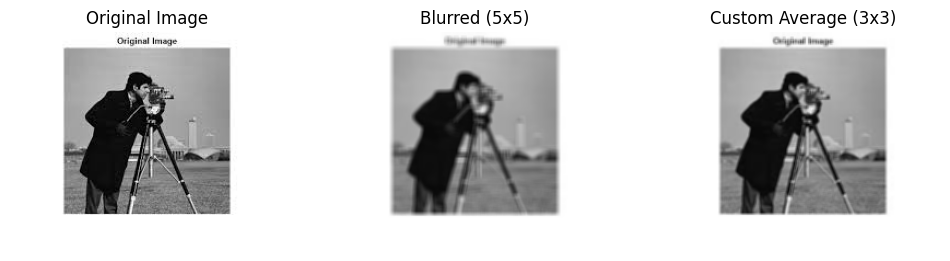

In [9]:
import cv2
import numpy as np
from matplotlib import pyplot as plt 
img = cv2.imread('image.png')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

blurred_img = cv2.blur(img_rgb, (5, 5)) 
kernel = np.ones((3,3), np.float32) / 9 
custom_avg = cv2.filter2D(img_rgb, -1, kernel) 
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(blurred_img)
plt.title('Blurred (5x5)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(custom_avg)
plt.title('Custom Average (3x3)')
plt.axis('off')

plt.show() 

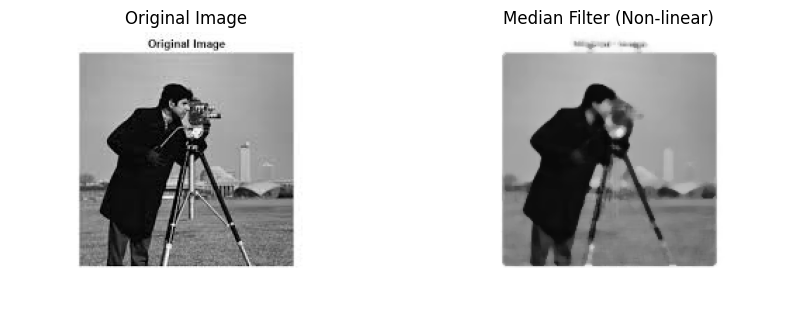

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt 
img = cv2.imread('image.png')
if img is None:
    print("Error")
else:
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    median_img = cv2.medianBlur(img_rgb, 5)
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off') 


    plt.subplot(1, 2, 2)
    plt.imshow(median_img)
    plt.title('Median Filter (Non-linear)')
    plt.axis('off')

    plt.show() 

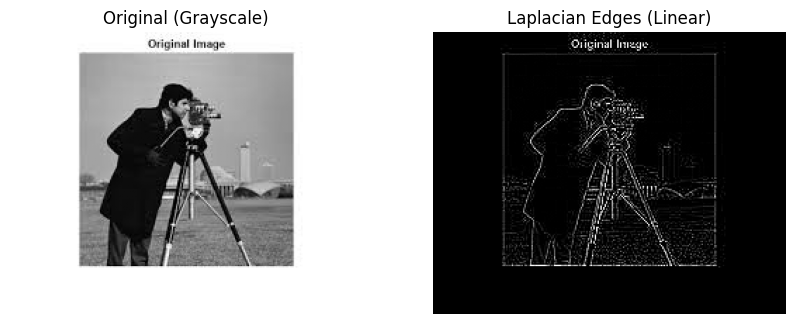

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt 
img = cv2.imread('image.png', 0)

if img is None:
    print("Error")
else:
    laplacian_kernel = np.array([[0,  1, 0],
                                 [1, -4, 1],
                                 [0,  1, 0]])


    edge_img = cv2.filter2D(img, -1, laplacian_kernel)
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original (Grayscale)')
    plt.axis('off')
    plt.subplot(1, 2, 2)

    plt.imshow(np.abs(edge_img), cmap='gray') 
    plt.title('Laplacian Edges (Linear)')
    plt.axis('off')

    plt.show() 